# Imports:

In [180]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

# Datasets:

In [181]:
df_irregular = pd.read_csv("data/smell.csv")

In [182]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9558.03it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [183]:
pca = PCA(n_components=2)

# Regular Dataset

Printing the head of the dataset

# Regular Dataset

Creating the regular baseline dataset from the Smell Pittsburgh dataset.

Printing the head of the dataset to compare to the final result.

In [184]:
print(df_irregular.head())

   epoch time                 date & time  smell value  skewed latitude  \
0  1577836610  01/01/2020 00:56:50 +01:00            3        40.557110   
1  1577850486  01/01/2020 04:48:06 +01:00            3        40.423138   
2  1577852394  01/01/2020 05:19:54 +01:00            3        40.381115   
3  1577857682  01/01/2020 06:48:02 +01:00            3        40.307728   
4  1577883411  01/01/2020 13:56:51 +01:00            3        40.307781   

   skewed longitude  zipcode                                smell description  \
0        -80.059578    15237  Sulfur. Hydrogen Sulfide.  Clairton Coke Works.   
1        -79.920387    15217                                       Industrial   
2        -79.860985    15110                                      Industrial    
3        -79.860908    15037                                us steel clairton   
4        -79.860908    15037                               u s steel clairton   

                         symptoms  \
0  Sore throat and lungs.

Initiliaze the regular sampled dataset as a copy of the irregular dataset.

In [185]:
df_regular = df_irregular.copy()

Make the 'date & time' column the index of the new dataset. This is done in order to resample the data in the next step. The column is also made into a <i>datetime</i>, to ensure correct interpertation by pandas.

In [186]:
df_regular["date & time"] = pd.to_datetime(df_regular["date & time"], utc=True)
df_regular = df_regular.set_index("date & time").sort_index()

In [187]:
df_regular = df_regular.resample("1h").agg(count = ("smell value", "size"), mean_smell = ("smell value", "mean"), latitude_mean = ("skewed latitude", "mean"), longitude_mean = ("skewed longitude", "mean"), latitude_std = ("skewed latitude", "std"), longitude_std = ("skewed longitude", "std"))

df_regular["count"] = df_regular["count"].fillna(0)
df_regular["mean_smell"] = df_regular["mean_smell"].fillna(0)
df_regular["latitude_mean"] = df_regular["latitude_mean"].fillna(0)
df_regular["longitude_mean"] = df_regular["longitude_mean"].fillna(0)
df_regular["latitude_std"] = df_regular["latitude_std"].fillna(0)
df_regular["longitude_std"] = df_regular["longitude_std"].fillna(0)


In [188]:
first_multi_time = df_regular[df_regular["count"] > 10].index[0]
print(df_regular.loc[first_multi_time])

count             15.000000
mean_smell         3.333333
latitude_mean     40.398344
longitude_mean   -79.942551
latitude_std       0.082676
longitude_std      0.081963
Name: 2020-01-02 15:00:00+00:00, dtype: float64


In [189]:
print(df_regular.head())

                           count  mean_smell  latitude_mean  longitude_mean  \
date & time                                                                   
2019-12-31 23:00:00+00:00      1         3.0      40.557110      -80.059578   
2020-01-01 00:00:00+00:00      0         0.0       0.000000        0.000000   
2020-01-01 01:00:00+00:00      0         0.0       0.000000        0.000000   
2020-01-01 02:00:00+00:00      0         0.0       0.000000        0.000000   
2020-01-01 03:00:00+00:00      1         3.0      40.423138      -79.920387   

                           latitude_std  longitude_std  
date & time                                             
2019-12-31 23:00:00+00:00           0.0            0.0  
2020-01-01 00:00:00+00:00           0.0            0.0  
2020-01-01 01:00:00+00:00           0.0            0.0  
2020-01-01 02:00:00+00:00           0.0            0.0  
2020-01-01 03:00:00+00:00           0.0            0.0  


In [190]:
irregular_count = len(df_irregular)
print("Irregular (raw) number of reports:", irregular_count)

Irregular (raw) number of reports: 75251


In [191]:
count=("smell value", "size")

regular_count = df_regular["count"].sum()
print("Regular (resampled total reports):", regular_count)

Regular (resampled total reports): 75251


In [192]:
df_irregular["date & time"] = pd.to_datetime(df_irregular["date & time"], utc=True)
df_irregular = df_irregular.set_index("date & time").sort_index()

df_irregular["combined"] = (
    df_irregular["smell description"].fillna("") + " " +
    df_irregular["symptoms"].fillna("") + " " +
    df_irregular["additional comments"].fillna("")
)

text_hourly = df_irregular["combined"].resample("1h").apply(" ".join)

df_regular["combined"] = text_hourly.reindex(df_regular.index, fill_value="")

In [193]:
embeddings = model.encode(df_regular["combined"].tolist())

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)
 
df_regular["text_emb_1"] = embeddings_2d[:, 0]
df_regular["text_emb_2"] = embeddings_2d[:, 1]

In [194]:
print(df_regular.head)

<bound method NDFrame.head of                            count  mean_smell  latitude_mean  longitude_mean  \
date & time                                                                   
2019-12-31 23:00:00+00:00      1         3.0      40.557110      -80.059578   
2020-01-01 00:00:00+00:00      0         0.0       0.000000        0.000000   
2020-01-01 01:00:00+00:00      0         0.0       0.000000        0.000000   
2020-01-01 02:00:00+00:00      0         0.0       0.000000        0.000000   
2020-01-01 03:00:00+00:00      1         3.0      40.423138      -79.920387   
...                          ...         ...            ...             ...   
2025-12-31 15:00:00+00:00      0         0.0       0.000000        0.000000   
2025-12-31 16:00:00+00:00      0         0.0       0.000000        0.000000   
2025-12-31 17:00:00+00:00      0         0.0       0.000000        0.000000   
2025-12-31 18:00:00+00:00      0         0.0       0.000000        0.000000   
2025-12-31 19:00:00+00

In [195]:
df_regular.to_csv("smell_regular.csv")

## Visualizing the data

Different plots of the data, based on location and comments a day:

In [196]:
plt.figure(figsize=(8,6))

for i in df_irregular["year"].dropna().unique():
    subset = df_irregular[df_irregular["year"] == i]
    
    plt.scatter(subset["skewed longitude"], subset["skewed latitude"], label=str(i), s=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Report locations")
plt.legend(title="Year")

plt.show()

KeyError: 'year'

<Figure size 800x600 with 0 Axes>

In [ ]:
print(df_regular.columns)

Index(['epoch time', 'smell value', 'skewed latitude', 'skewed longitude',
       'zipcode', 'smell description', 'symptoms', 'additional comments'],
      dtype='object')


# Textual processing

The primarly method will be a TF-IDF. When the context given by this method is not sufficient we will use embeddings instead.

In [ ]:
df_irregular["smell description"] = df_irregular["smell description"].str.lower()
df_irregular["symptoms"] = df_irregular["symptoms"].str.lower()
df_irregular["additional comments"] = df_irregular["additional comments"].str.lower()

<b>TF-IDF for smell description</b>:

In [ ]:
tfidf_desc = TfidfVectorizer(stop_words="english", max_features=500)

X_desc = tfidf_desc.fit_transform(df_irregular["smell description"].fillna(""))

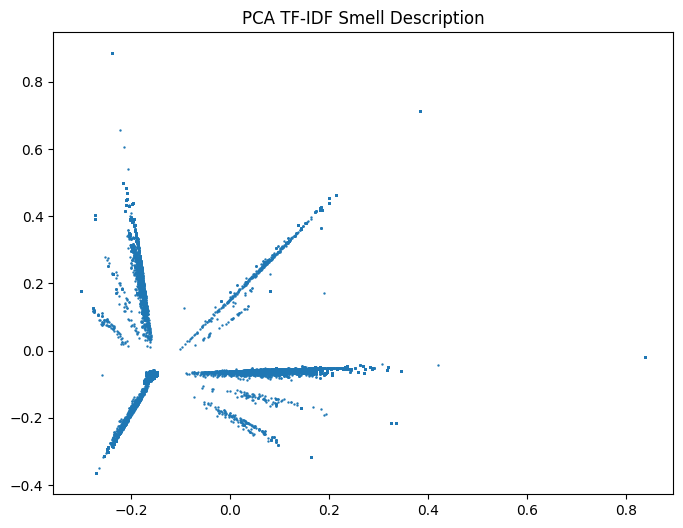

In [ ]:
X_pca = PCA(n_components=2).fit_transform(X_desc.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Smell Description")
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5)

<b>TF-IDF for symptoms</b>:

In [ ]:
tfidf_symptoms = TfidfVectorizer(stop_words="english", max_features=500)

X_symptoms = tfidf_symptoms.fit_transform(df_irregular["symptoms"].fillna(""))

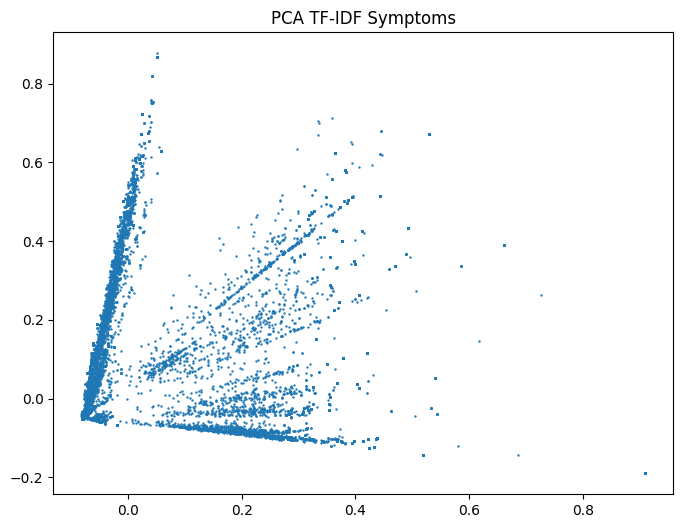

In [ ]:
X_pca = PCA(n_components=2).fit_transform(X_symptoms.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Symptoms")
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5)

<b>TF-IDF for additional comments:</b>:

In [ ]:
tfidf_comments = TfidfVectorizer(stop_words="english", max_features=500)

X_comments = tfidf_comments.fit_transform(df_irregular["additional comments"].fillna(""))

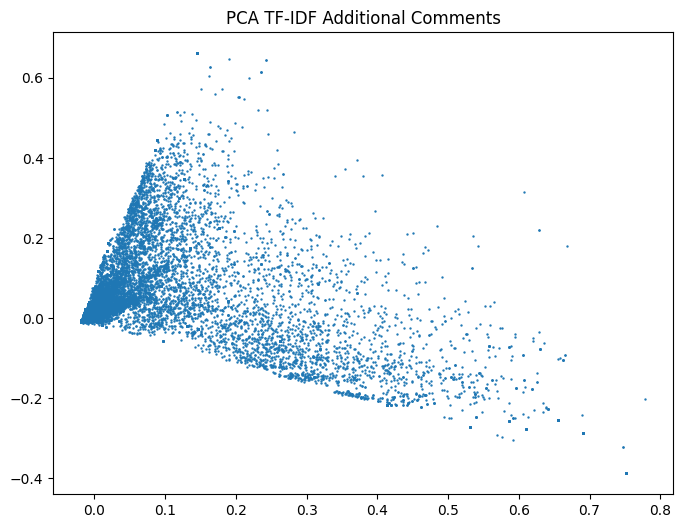

In [ ]:
X_pca = PCA(n_components=2).fit_transform(X_comments.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Additional Comments")
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5)

<b>TF-IDF combined:</b>:

Combining the three text fields into one:

In [ ]:
df_irregular["combined"] = df_irregular["smell description"].fillna("") + " " + df_irregular["symptoms"].fillna("") + " " + df_irregular["additional comments"].fillna("")

In [ ]:
tfidf_comments = TfidfVectorizer(stop_words="english", max_features=500)

X_combined= tfidf_comments.fit_transform(df_irregular["combined"].fillna(""))

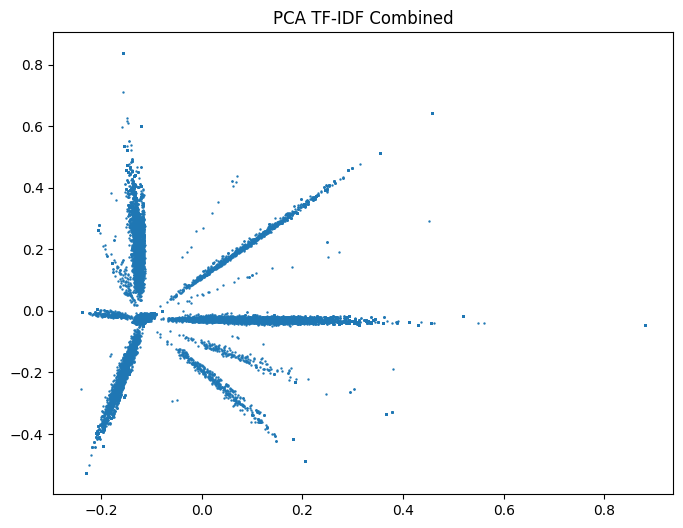

In [ ]:
X_pca = PCA(n_components=2).fit_transform(X_combined.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Combined")
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5)

## Using Embeddings

The plot above shows that the TF-IDF might be too simple. We analyze that there are many spokes, which means that many points are in the same direction. The model is too simple to get proper meaning out of it. A better options will be embeddings.

c:\Users\thoma\AppData\Local\Programs\Python\Python314\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\thoma\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 704.46it/s]
BertMod

KeyError: 'combined'

In [ ]:

embeddings_2d =

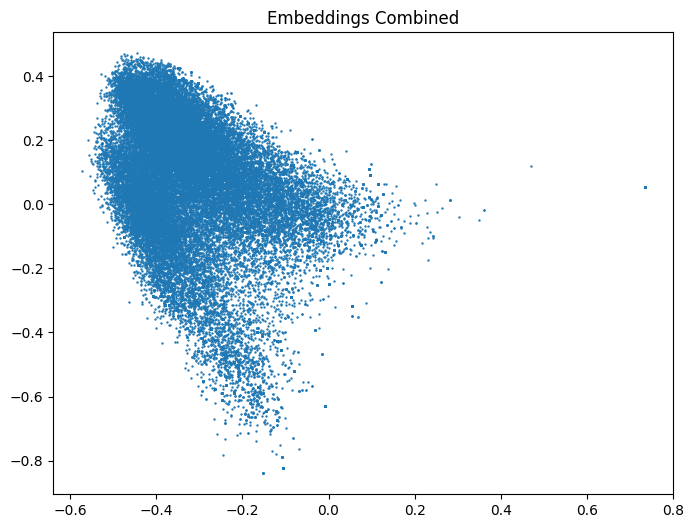

In [ ]:
plt.figure(figsize=(8,6))
plt.title("Embeddings Combined")
plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1], s=0.5)

# MMD on regular dataset